In [1]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"ayus132","key":"5b0d2b2703f6b4fb43a87b66aec62549"}'}

In [2]:
mv "kaggle (2).json" kaggle.json

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
ls

kaggle.json  sample_data/


In [5]:
!mkdir -p ~/.kaggle

In [6]:
!cp kaggle.json ~/.kaggle/

In [7]:
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle datasets list

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
wardabilal/spotify-global-music-dataset-20092025                   Spotify Global Music Dataset (2009–2025)               1289021  2025-11-11 09:43:05.933000          13607        305  1.0              
ranaghulamnabi/shopping-behavior-and-preferences-study             Shopping Behavior & Preferences Study                    72157  2025-12-03 09:14:26.797000           1393         33  1.0              
rohiteng/amazon-sales-dataset                                      Amazon Sales Dataset                                   4037578  2025-11-23 14:29:37.973000           4947         70  1.0

In [9]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset


Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 85% 139M/163M [00:00<00:00, 1.46GB/s]
100% 163M/163M [00:00<00:00, 1.31GB/s]


In [10]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [12]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [13]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_3404.jpg', 'with_mask_114.jpg', 'with_mask_602.jpg', 'with_mask_3081.jpg', 'with_mask_243.jpg']
['with_mask_3412.jpg', 'with_mask_1354.jpg', 'with_mask_2930.jpg', 'with_mask_880.jpg', 'with_mask_2091.jpg']


In [14]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1330.jpg', 'without_mask_1267.jpg', 'without_mask_1003.jpg', 'without_mask_2478.jpg', 'without_mask_1533.jpg']
['without_mask_2298.jpg', 'without_mask_2540.jpg', 'without_mask_2550.jpg', 'without_mask_2063.jpg', 'without_mask_2471.jpg']


In [15]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


Creating Labels for the two class of Images

with mask --> 1

without mask --> 0

In [16]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [17]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [18]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [19]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying th**e **bold text** **Images**

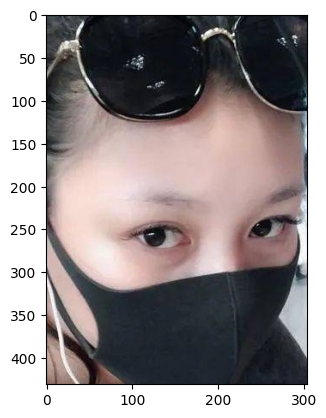

In [20]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1149.jpg')
imgplot = plt.imshow(img)
plt.show()

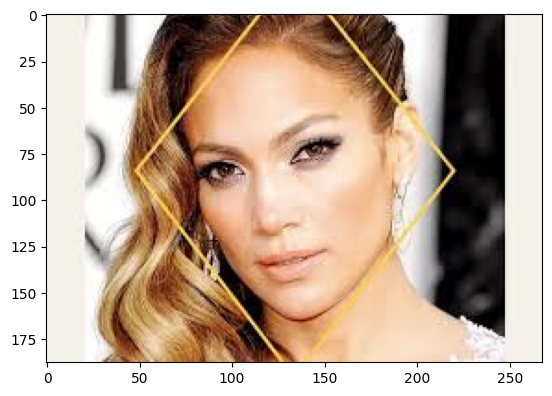

In [29]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2929.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1) Resize the Images

2) Convert the images to numpy arrays

In [30]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [31]:
type(data)

list

In [32]:
len(data)

7553

array([[[231, 222, 207],
        [236, 227, 212],
        [236, 227, 211],
        ...,
        [ 50,  51,  55],
        [ 47,  53,  55],
        [ 48,  50,  56]],

       [[233, 224, 211],
        [229, 219, 206],
        [239, 229, 217],
        ...,
        [ 50,  52,  56],
        [ 49,  54,  58],
        [ 49,  52,  58]],

       [[238, 228, 217],
        [234, 224, 214],
        [240, 229, 221],
        ...,
        [ 50,  55,  58],
        [ 50,  56,  61],
        [ 50,  53,  62]],

       ...,

       [[101, 106, 101],
        [110, 122, 122],
        [111, 122, 120],
        ...,
        [133, 139, 135],
        [116, 121, 116],
        [110, 113, 106]],

       [[ 57,  47,  38],
        [ 85,  84,  81],
        [107, 112, 106],
        ...,
        [134, 139, 135],
        [117, 122, 117],
        [110, 114, 106]],

       [[ 47,  30,  21],
        [ 47,  33,  26],
        [ 60,  54,  47],
        ...,
        [134, 139, 135],
        [118, 124, 118],
        [110, 114, 106]]], dtype=uint8)
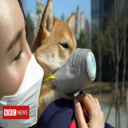

In [33]:
data[0]

In [34]:
type(data[0])

numpy.ndarray

In [35]:
data[0].shape

(128, 128, 3)

In [36]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [37]:
type(X)

numpy.ndarray

In [38]:
type(Y)

numpy.ndarray

In [39]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [40]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Split**

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [42]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [43]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[63, 65, 51],
        [51, 53, 39],
        [44, 45, 31],
        ...,
        [70, 55, 36],
        [69, 55, 36],
        [67, 56, 36]],

       [[52, 52, 36],
        [44, 44, 28],
        [38, 38, 22],
        ...,
        [72, 58, 41],
        [70, 57, 40],
        [68, 57, 39]],

       [[47, 44, 26],
        [43, 41, 22],
        [41, 38, 22],
        ...,
        [69, 57, 42],
        [69, 56, 42],
        [72, 59, 44]],

       ...,

       [[78, 61, 55],
        [75, 61, 55],
        [71, 60, 58],
        ...,
        [34, 36, 35],
        [40, 42, 41],
        [47, 52, 48]],

       [[84, 67, 59],
        [81, 66, 60],
        [77, 65, 62],
        ...,
        [27, 29, 28],
        [29, 32, 30],
        [38, 44, 40]],

       [[88, 70, 63],
        [85, 70, 63],
        [81, 69, 65],
        ...,
        [24, 26, 25],
        [25, 28, 27],
        [31, 37, 33]]], dtype=uint8)
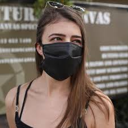

In [44]:
X_train[0]

In [45]:
X_train_scaled[0]

array([[[0.24705882, 0.25490196, 0.2       ],
        [0.2       , 0.20784314, 0.15294118],
        [0.17254902, 0.17647059, 0.12156863],
        ...,
        [0.2745098 , 0.21568627, 0.14117647],
        [0.27058824, 0.21568627, 0.14117647],
        [0.2627451 , 0.21960784, 0.14117647]],

       [[0.20392157, 0.20392157, 0.14117647],
        [0.17254902, 0.17254902, 0.10980392],
        [0.14901961, 0.14901961, 0.08627451],
        ...,
        [0.28235294, 0.22745098, 0.16078431],
        [0.2745098 , 0.22352941, 0.15686275],
        [0.26666667, 0.22352941, 0.15294118]],

       [[0.18431373, 0.17254902, 0.10196078],
        [0.16862745, 0.16078431, 0.08627451],
        [0.16078431, 0.14901961, 0.08627451],
        ...,
        [0.27058824, 0.22352941, 0.16470588],
        [0.27058824, 0.21960784, 0.16470588],
        [0.28235294, 0.23137255, 0.17254902]],

       ...,

       [[0.30588235, 0.23921569, 0.21568627],
        [0.29411765, 0.23921569, 0.21568627],
        [0.27843137, 0

**Building a Convolutional Neural Networks (CNN)**

In [46]:
import tensorflow as tf
from tensorflow import keras

In [47]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

In [48]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [49]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 137s 794ms/step - acc: 0.6699 - loss: 0.9090 - val_acc: 0.8843 - val_loss: 0.3119
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 133s 785ms/step - acc: 0.8769 - loss: 0.3208 - val_acc: 0.8314 - val_loss: 0.4086
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 135s 797ms/step - acc: 0.8878 - loss: 0.2786 - val_acc: 0.8992 - val_loss: 0.2550
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 138s 777ms/step - acc: 0.9152 - loss: 0.2244 - val_acc: 0.9058 - val_loss: 0.2635
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 131s 771ms/step - acc: 0.9271 - loss: 0.1878 - val_acc: 0.9058 - val_loss: 0.2306


**Model Evaluation**

In [50]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 221ms/step - acc: 0.9249 - loss: 0.1951
Test Accuracy = 0.9199205636978149


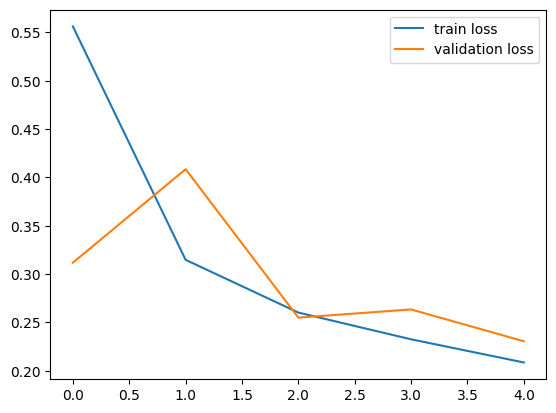

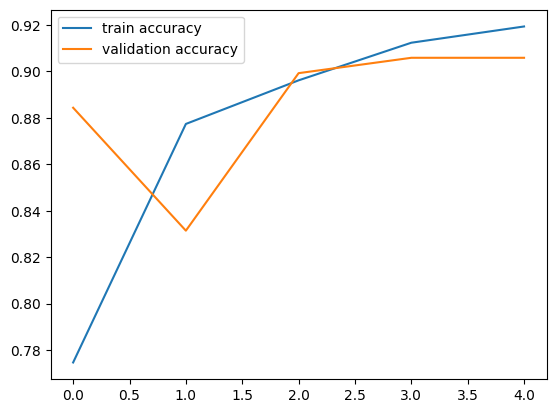

In [51]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Predictive System**

Path of the image to be predicted: /content/photo.jpg


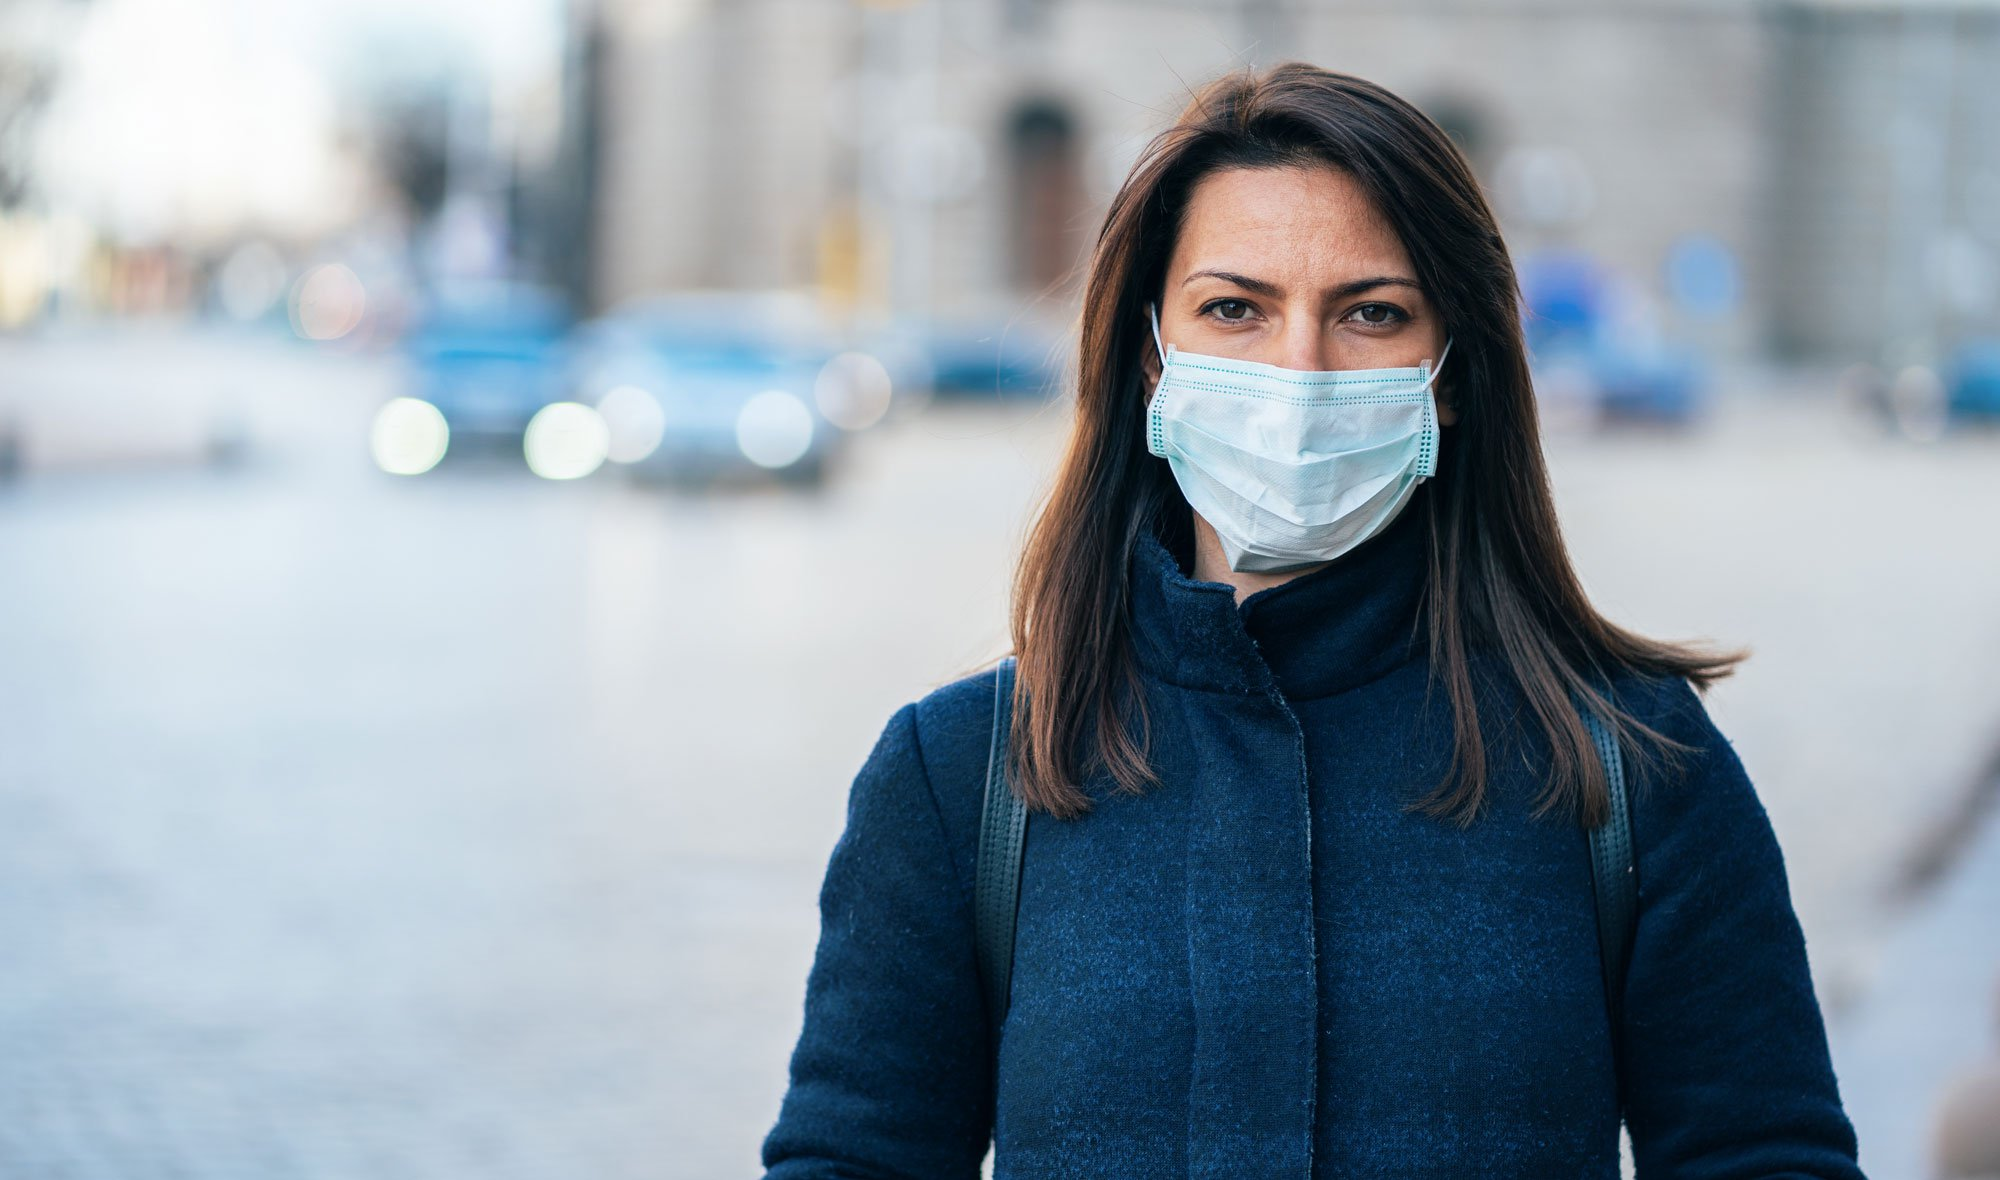

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
[[0.21522821 0.57308257]]
1
The person in the image is wearing a mask


In [53]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')